Code from https://github.com/derekgreene/topic-model-tutorial

In [ ]:
from pathlib import Path
import re, joblib
from itertools import combinations
import numpy as np
from sklearn import decomposition
import gensim
import matplotlib
import matplotlib.pyplot as plt
# settings for our plots later
plt.style.use("ggplot")
matplotlib.rcParams.update({"font.size": 14})

In [2]:
from nltk.corpus import stopwords
import nltk
import unicodedata
import glob

nltk.download("stopwords")

spanish_stopwords = stopwords.words("spanish")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/ssparzival/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
directory_path = "../data/lemmas_individual/"
text_files = glob.glob(f"{directory_path}/*.txt")

In [4]:
raw_documents = []

for text in text_files:
    with open(text, "r", encoding="latin1") as f:
        content = f.read()
        content = unicodedata.normalize("NFKD", content)
        content = "".join([c for c in content if not unicodedata.combining(c)])
        raw_documents.append(content)

raw_documents[:2]

['el jueves dia del corriente el perder uno cholito llamado melchora vidal del callejon de pelateros n de el provincia de conchucos a el persona que dierar razon de su paradero el el darir uno gratificacion',
 'el haber perder uno cholito como de edad de ocho ano gordo cara redonda ancho de espalda ojo grande nariz romo su nombre santos con chaqueta azul y pantalon de dril de amotape el persona que el haber encontrar el servirar a da gregoria helguero su madrina en el tiraduria de el calle de judios donde el el darir uno gratificacion a el persona que el entregar o dar razon de su paradero']

In [5]:
(A, terms, snippets) = joblib.load("../data/avisos-tfidf.pkl")
print("Loaded %d X %d document-term matrix" % (A.shape[0], A.shape[1]))

Loaded 593 X 2859 document-term matrix


In [6]:
kmin, kmax = 4, 15

In [7]:
topic_models = []
# try each value of k
for k in range(kmin, kmax + 1):
    print("Applying NMF for k=%d ..." % k)
    # run NMF
    model = decomposition.NMF(init="nndsvd", n_components=k, max_iter=100000)
    W = model.fit_transform(A)
    H = model.components_
    # store for later
    topic_models.append((k, W, H))

Applying NMF for k=4 ...
Applying NMF for k=5 ...
Applying NMF for k=6 ...
Applying NMF for k=7 ...
Applying NMF for k=8 ...
Applying NMF for k=9 ...
Applying NMF for k=10 ...
Applying NMF for k=11 ...
Applying NMF for k=12 ...
Applying NMF for k=13 ...
Applying NMF for k=14 ...
Applying NMF for k=15 ...


In [8]:
class TokenGenerator:
    def __init__(self, documents, stopwords):
        self.documents = documents
        self.stopwords = stopwords
        self.tokenizer = re.compile(r"(?u)\b\w\w+\b")

    def __iter__(self):
        print("Building Word2Vec model ...")
        for doc in self.documents:
            tokens = []
            for tok in self.tokenizer.findall(doc):
                if tok in self.stopwords:
                    tokens.append("<stopword>")
                elif len(tok) >= 2:
                    tokens.append(tok)
            yield tokens

In [9]:
docgen = TokenGenerator(raw_documents, spanish_stopwords)
w2v_model = gensim.models.Word2Vec(docgen, min_count=10, sg=1)

Building Word2Vec model ...
Building Word2Vec model ...
Building Word2Vec model ...
Building Word2Vec model ...
Building Word2Vec model ...
Building Word2Vec model ...


In [10]:
print("Model has %d terms" % len(w2v_model.wv.key_to_index))

Model has 362 terms


In [11]:
w2v_model.save("../data/w2v-model.bin")

In [12]:
def calculate_coherence(w2v_model, term_rankings):
    overall_coherence = 0.0
    for topic_index in range(len(term_rankings)):
        pair_scores = []
        for pair in combinations(term_rankings[topic_index], 2):
            try:
                pair_scores.append(w2v_model.wv.similarity(pair[0], pair[1]))
            except KeyError:
                # Skip this pair if either word is not in the model vocabulary
                continue
        if pair_scores:  # Avoid division by zero if all pairs were skipped
            topic_score = sum(pair_scores) / len(pair_scores)
        else:
            topic_score = 0.0
        overall_coherence += topic_score
    return overall_coherence / len(term_rankings)

In [13]:
def get_descriptor(all_terms, H, topic_index, top):
    # reverse sort the values to sort the indices
    top_indices = np.argsort(H[topic_index, :])[::-1]
    # now get the terms corresponding to the top-ranked indices
    top_terms = []
    for term_index in top_indices[0:top]:
        top_terms.append(all_terms[term_index])
    return top_terms

In [14]:
k_values = []
coherences = []
for k, W, H in topic_models:
    # Get all of the topic descriptors - the term_rankings, based on top 10 terms
    term_rankings = []
    for topic_index in range(k):
        term_rankings.append(get_descriptor(terms, H, topic_index, 10))
    # Now calculate the coherence based on our Word2vec model
    k_values.append(k)
    coherences.append(calculate_coherence(w2v_model, term_rankings))
    print("K=%02d: Coherence=%.4f" % (k, coherences[-1]))

K=04: Coherence=0.7344
K=05: Coherence=0.7956
K=06: Coherence=0.7773
K=07: Coherence=0.7797
K=08: Coherence=0.7703
K=09: Coherence=0.7603
K=10: Coherence=0.7545
K=11: Coherence=0.7379
K=12: Coherence=0.7038
K=13: Coherence=0.7006
K=14: Coherence=0.7316
K=15: Coherence=0.7073


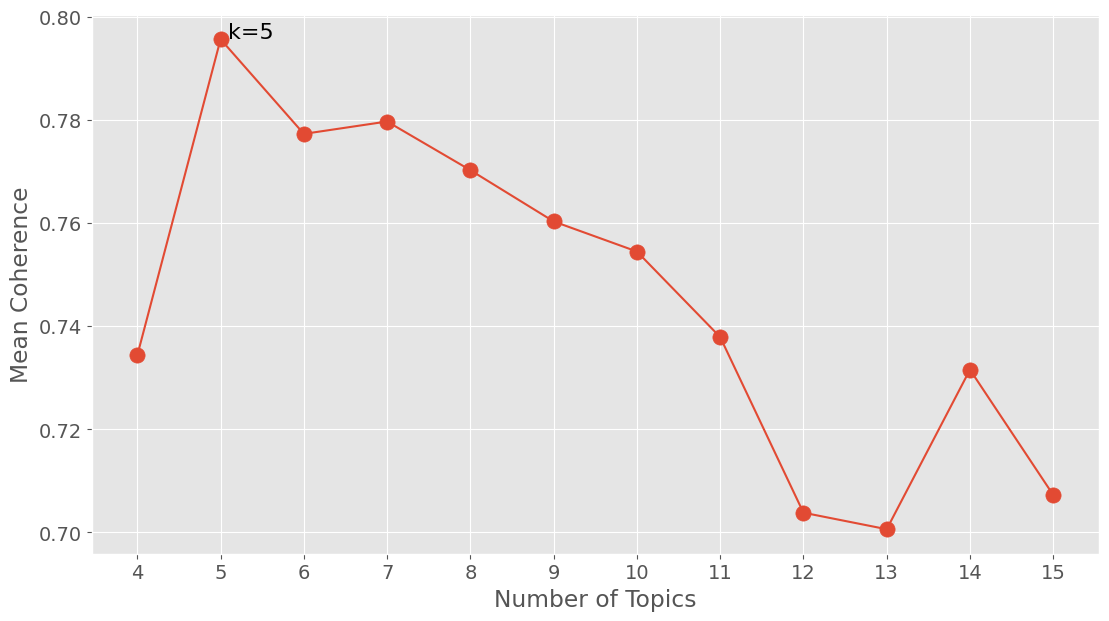

In [15]:
fig = plt.figure(figsize=(13, 7))
# create the line plot
ax = plt.plot(k_values, coherences)
plt.xticks(k_values)
plt.xlabel("Number of Topics")
plt.ylabel("Mean Coherence")
# add the points
plt.scatter(k_values, coherences, s=120)
# find and annotate the maximum point on the plot
ymax = max(coherences)
xpos = coherences.index(ymax)
best_k = k_values[xpos]
plt.annotate(
    "k=%d" % best_k,
    xy=(best_k, ymax),
    xytext=(best_k, ymax),
    textcoords="offset points",
    fontsize=16,
)
# show the plot
plt.show()

In [16]:
k = best_k
# get the model that we generated earlier.
W = topic_models[k - kmin][1]
H = topic_models[k - kmin][2]

In [17]:
for topic_index in range(k):
    descriptor = get_descriptor(terms, H, topic_index, 10)
    str_descriptor = ", ".join(descriptor)
    print("Topic %02d: %s" % (topic_index + 1, str_descriptor))

Topic 01: casa, policia, haber, reglamento, tener, poder, ser, hacer, persona, patron
Topic 02: comercio, repetir, diciembre, junio, septiembre, enero, febrero, julio, noviembre, marzo
Topic 03: dar, razon, imprenta, persona, paradero, cholito, haber, ano, gratificacion, edad
Topic 04: ojo, cara, nariz, pequeno, boca, regular, ser, redonda, grande, senal
Topic 05: pantalon, azul, color, sombrero, camisa, vestido, muchacho, pano, negro, blanco
